# GOES-18 ABI True Color — Shishaldin

A single True Color image over Shishaldin on 3 October 2023, 19:00 UTC.

True Color needs sunlight (daytime). ABI has no green band, so green is
synthesised from the blue, red, and vegetation channels. See
[docs/RGB.md](../docs/RGB.md#goes-abi-true-color-with-synthetic-green).

For an image that also works at night, see
[`05_GOES_day_night.ipynb`](05_GOES_day_night.ipynb).

## Setup

In [1]:
import logging
import sys
import warnings
from pathlib import Path

from IPython.display import Image, display
from satpy import Scene
from satpy.utils import PerformanceWarning

logging.getLogger("pyspectral.rsr_reader").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.domains import DOMAINS
from examples.goes18_coverage_data import SCAN_LABELS, download_coverage
from examples.render_satellite import crop_and_resample_scene, save_map


## Parameters

In [2]:
PRODUCT_LABEL = "True Color"

# One named domain from examples/domains.py (edit it there for your own area).
DOMAIN_NAME = "shishaldin"
DOMAIN = DOMAINS[DOMAIN_NAME]
DOMAIN_RESOLUTION = 0.02

CHANNELS = ("C01", "C02", "C03")
COMPOSITE = "true_color"

DATA_DIR = REPO_ROOT / "data" / "goes18-20231003-1900"
OUTPUT = REPO_ROOT / "output" / "goes18_true_color_shishaldin.png"
OUTPUT.parent.mkdir(parents=True, exist_ok=True)


## Render

Download the True Color channels (`C01`, `C02`, `C03`), build the
composite, crop to the Shishaldin domain, and save one image with a
longitude/latitude grid and coastlines.

The following datasets were not created and may require resampling to be generated: DataID(name='true_color')


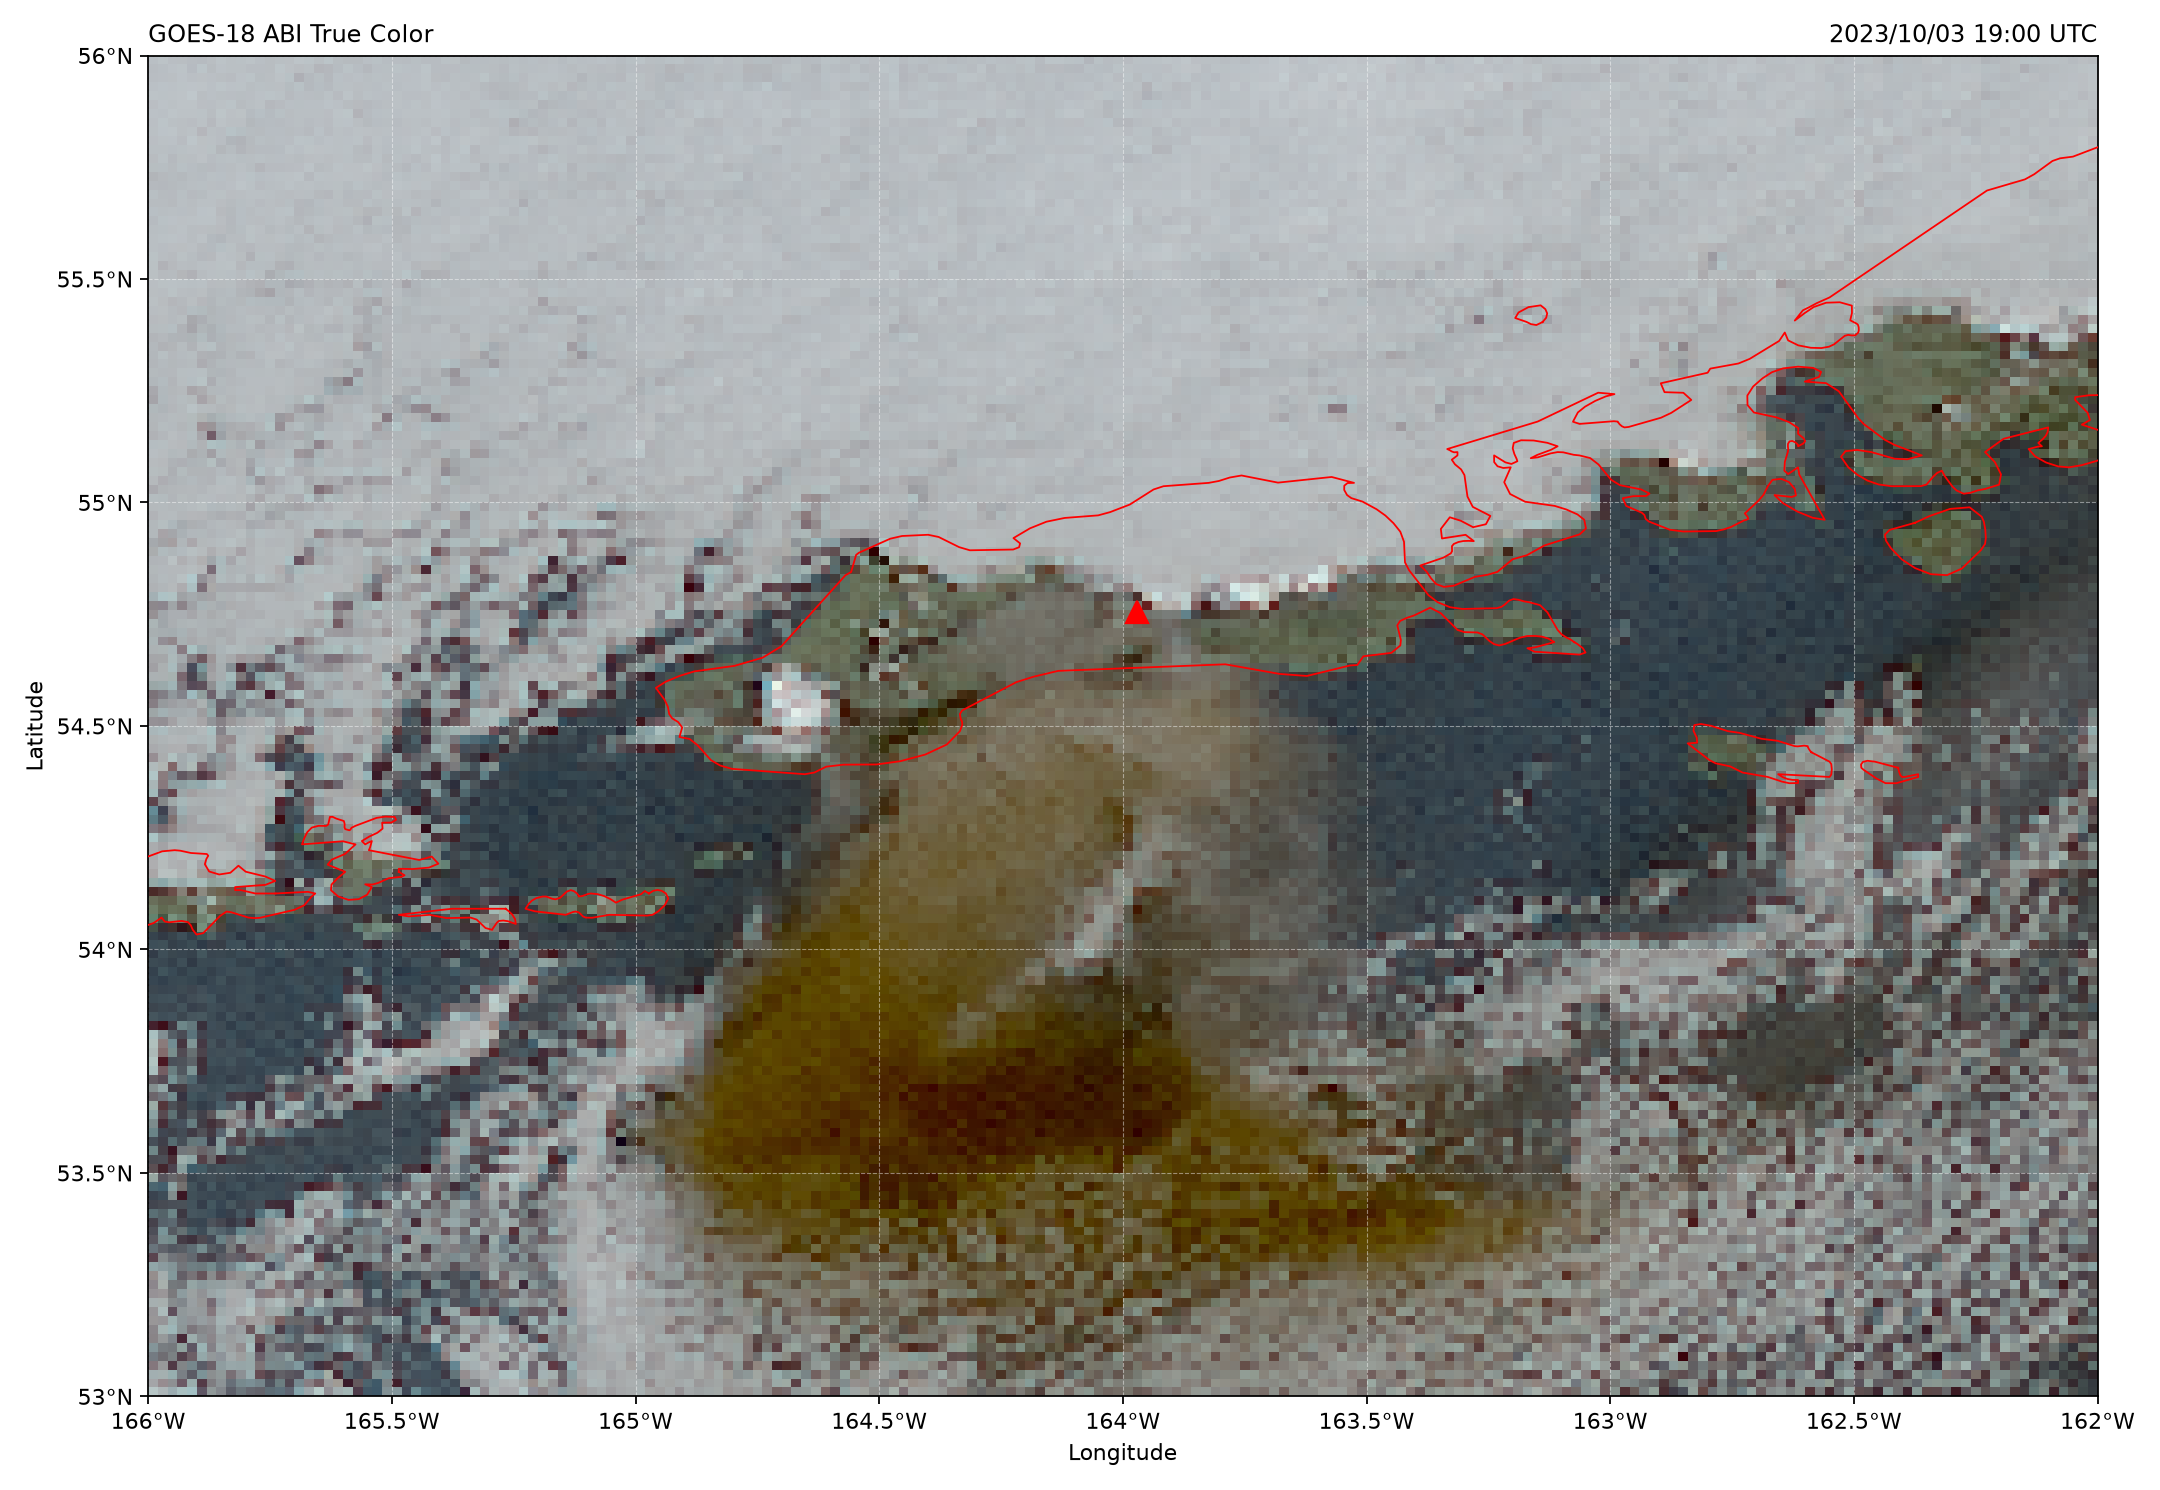

In [3]:
files = download_coverage(DATA_DIR, "full_disk", CHANNELS)
scene = Scene(reader="abi_l1b", filenames=files)
scene.load([COMPOSITE], generate=True)

# Read from the ABI projection, then put the crop on a regular lon/lat grid
# (EPSG:4326 is plain rectangular over this small domain).
cropped = crop_and_resample_scene(scene, domain=DOMAIN, resolution=DOMAIN_RESOLUTION)
try:
    cropped[COMPOSITE]
except KeyError:
    cropped.load([COMPOSITE], generate=True)

save_map(
    cropped,
    COMPOSITE,
    OUTPUT,
    title=f"GOES-18 ABI {PRODUCT_LABEL}",
)
display(Image(filename=str(OUTPUT)))


## Notes

* The brown streak south of the volcano is the Shishaldin ash plume.
* Change `DOMAIN_NAME` to any name from `examples/domains.py`, or set
  `DOMAIN` to your own `(min_lon, min_lat, max_lon, max_lat)` box.
* Command line: `python examples/render_satellite.py --sensor goes --files "data/goes/*.nc" --composite true_color --domain shishaldin`.